In [27]:
import os

import torch
from torch.utils.data import DataLoader
import numpy as np
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

In [4]:
LATENT_SIZE = 32
BATCH_SIZE = 32
DATA_PATH = "../data"

In [5]:
os.makedirs(DATA_PATH, exist_ok=True)
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.1307,), (0.3081,))
])
train_data = torchvision.datasets.MNIST(DATA_PATH, download=True, transform=transform, train=True)
test_data = torchvision.datasets.MNIST(DATA_PATH, download=True, transform=transform, train=False)

In [6]:
train_dataloader = DataLoader(train_data, BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, BATCH_SIZE, shuffle=False)

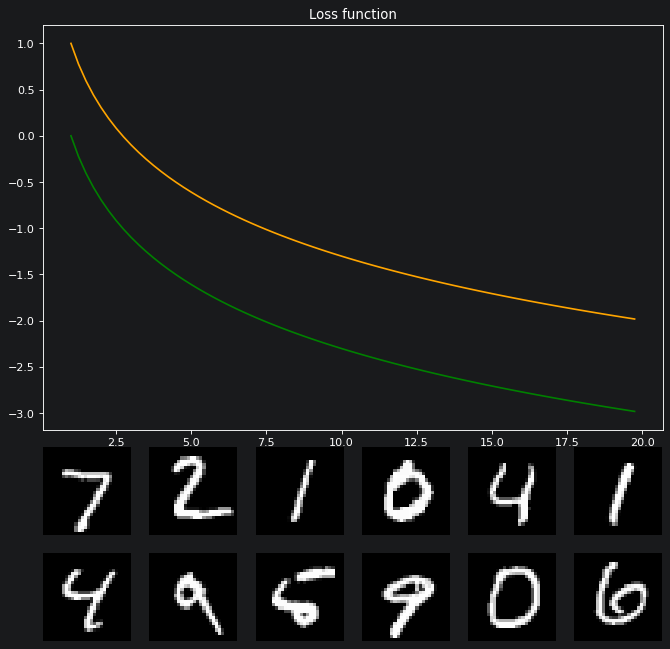

In [38]:
fig = plt.figure(figsize=(10, 10), dpi=80)

gridspec = GridSpec(6, 6)
X = np.arange(1, 20, step=0.25)
Y = -np.log(X)

ax1 = plt.subplot(gridspec[0:4, :])
ax1.plot(X, Y, color="green", label="KL")
ax1.plot(X, Y + 1, color="orange", label="L2")
ax1.set_title("Loss function")

for i in range(6):
    ax = plt.subplot(gridspec[4, i])
    ax.axis("off")
    ax.imshow(test_data[i][0].squeeze().numpy(), cmap="grey")

for i in range(6):
    ax = plt.subplot(gridspec[5, i])
    ax.axis("off")
    ax.imshow(test_data[i + 6][0].squeeze().numpy(), cmap="grey")
